# 06 — From electric field to ADC counts

Notebooks 03–05 covered the pieces. This one runs the whole thing:

```
E-field trace  ->  antenna (03)  ->  RF chain (04)  ->  + noise (05)  ->  ADC
```

`Efield2Voltage` drives it: it reads a ROOT file holding `TRun`, `TEfield` and
`TShower`, applies every stage, and writes a `TVoltage` tree back out.

We build the input here rather than downloading one, so the notebook runs on a
fresh checkout and the contents of the fixture are visible rather than opaque —
the same approach as `tests/sim/test_pipeline_end_to_end.py`.

In [1]:
import itertools
import os
import tempfile

import numpy as np
import matplotlib.pyplot as plt

from grand import Efield2Voltage
from grand.dataio.event_trees import TEfield, TShower, TVoltage
from grand.dataio.run_trees import TRun

# Everything this notebook writes goes into a temporary directory that the last
# cell removes.  Nothing is left in the repository.
workdir = tempfile.mkdtemp(prefix='grand-nb06-')

# Each run of the chain needs its own output file: writing two events with the
# same (run_number, event_number) into one tree raises NotUniqueEvent.
counter = itertools.count()

print("working in", workdir)

working in /tmp/grand-nb06-qgt4jaot


## 1. Building an input file

Three detection units, each carrying a Gaussian pulse. The three field
components get different amplitudes (1.0, 0.6, 0.2) on purpose: with equal
amplitudes a component swap somewhere in the chain would be invisible.

The peak field is **500 µV/m**, which is a strong but unremarkable shower.
That number matters — see section 3.

In [2]:
N_DU, N_SAMPLES, T_BIN_NS = 3, 512, 0.5
PEAK_NS, WIDTH_NS = 120.0, 4.0
E_PEAK = 500.0                       # microvolts per metre
SITE = [40.98, 93.95, 1200.0]        # GRANDProto300: lat, lon, altitude

path = os.path.join(workdir, 'efield.root')

# --- TRun: everything constant across the events of one run ------------------
# Constructing a tree on a file that has no such tree prints "No valid trun
# TTree ... Creating a new one" -- that is the expected path when writing.
run = TRun(path)
run.run_number = 0
run.du_id = list(range(N_DU))
run.du_xyz = [[0., 0., 0.], [500., 0., 0.], [0., 500., 0.]]   # metres, site frame
run.t_bin_size = [T_BIN_NS] * N_DU                            # nanoseconds
run.origin_geoid = SITE
run.fill()          # commit this entry to the in-memory tree
run.write()         # flush the tree to the file

# --- TEfield: the per-event traces ------------------------------------------
t_ns = np.arange(N_SAMPLES) * T_BIN_NS
pulse = E_PEAK * np.exp(-((t_ns - PEAK_NS) ** 2) / (2 * WIDTH_NS ** 2))

# Shape (du, component, sample).  float32 because that is what the branch holds;
# passing float64 works but round-trips lossily and hides real differences.
trace = np.stack([np.stack([pulse * a for a in (1.0, 0.6, 0.2)])
                  for _ in range(N_DU)]).astype(np.float32)

efield = TEfield(path)
efield.run_number, efield.event_number = 0, 0
efield.du_id = list(range(N_DU))
efield.du_nanoseconds = [0] * N_DU
efield.du_seconds = [0] * N_DU
efield.trace = trace
efield.fill(); efield.write()

# --- TShower: the geometry the antenna response is evaluated for -------------
shower = TShower(path)
shower.run_number, shower.event_number = 0, 0
shower.zenith, shower.azimuth = 85.0, 0.0      # a very inclined shower
shower.energy_primary = 3.98e9                 # GeV
shower.shower_core_pos = [0., 0., 1200.]
shower.xmax_pos_shc = [0., 0., 10000.]         # shower-core frame, not the site frame
shower.fill(); shower.write()

print("wrote %s  (%.1f kB)" % (path, os.path.getsize(path) / 1e3))
print("E-field trace:", trace.shape, " (du, component, sample)")

No valid trun TTree in the file /tmp/grand-nb06-qgt4jaot/efield.root. Creating a new one.


No valid tefield TTree in the file /tmp/grand-nb06-qgt4jaot/efield.root. Creating a new one.


No valid tshower TTree in the file /tmp/grand-nb06-qgt4jaot/efield.root. Creating a new one.


wrote /tmp/grand-nb06-qgt4jaot/efield.root  (28.2 kB)
E-field trace: (3, 3, 512)  (du, component, sample)


A note on units and conventions, which is where most first attempts go wrong:

- E-field traces are in **µV/m** (`event_trees.py` says so on the
  peak-to-peak fields).
- `t_bin_size` is in **nanoseconds**, so 0.5 ns is a 2 GHz sampling rate.
- `zenith` is measured from the vertical, so 85° is 5° above the horizon —
  the very inclined geometry GRAND is built for.
- `origin_geoid` is `[latitude, longitude, altitude]` in degrees and metres;
  everything angular in GRANDlib is in **degrees**, never radians.
- `xmax_pos_shc` is in the shower-core frame, not the site frame.

## 2. Running the chain

`Efield2Voltage` takes an input path, an output path and a seed. The seed
makes the noise reproducible, which is what makes the stage-by-stage comparison
below meaningful.

In [3]:
def run_chain(**params):
    """Runs the chain once on the fixture and returns the simulator.

    Any keyword given here overrides an entry of ``sim.params``; the defaults
    are printed below.  Each call writes to a fresh output file.
    """
    out = os.path.join(workdir, 'voltage_%d.root' % next(counter))
    sim = Efield2Voltage(path, out, seed=0)
    sim.params.update(params)
    sim.compute_voltage()
    sim.output_path = out          # remembered so section 7 can read it back
    return sim

full_sim = run_chain()
vout = np.asarray(full_sim.vout)   # (du, arm, sample), microvolts
print("output:", vout.shape, " peak |V| = %.3g uV" % np.abs(vout).max())
print()
print("params in effect:")
for k, v in sorted(full_sim.params.items()):
    print("   %-28s %s" % (k, v))

No valid tvoltage TTree in the file /tmp/grand-nb06-qgt4jaot/voltage_0.root. Creating a new one.


output: (3, 3, 512)  peak |V| = 6.38e+03 uV

params in effect:
   add_jitter_ns                0
   add_noise                    True
   add_rf_chain                 True
   add_rf_chain_gaa             False
   add_rf_chain_nut             False
   calibration_smearing_sigma   0
   extend_to_us                 0
   lst                          18.0
   resample_to_mhz              0


## 3. Isolating each stage

Two flags switch stages off. Running the chain three times shows what each
contributes.

Because the seed is fixed, `full − chain` is *exactly* the noise that was
added. That gives an honest signal-to-noise number, rather than one estimated
from "the quiet part of the trace" — which does not exist here, because the
band-limited ringing spreads the pulse across the whole window.

No valid tvoltage TTree in the file /tmp/grand-nb06-qgt4jaot/voltage_1.root. Creating a new one.


No valid tvoltage TTree in the file /tmp/grand-nb06-qgt4jaot/voltage_2.root. Creating a new one.


unit 0, per arm (X, Y, Z):
   V_oc peak        [158.4 101.2   0.4]
   + chain peak     [6076.7 3824.2    9.7]
   noise RMS        [ 631.9 1005.3  582.4]
   signal / noise   [9.6 3.8 0. ]


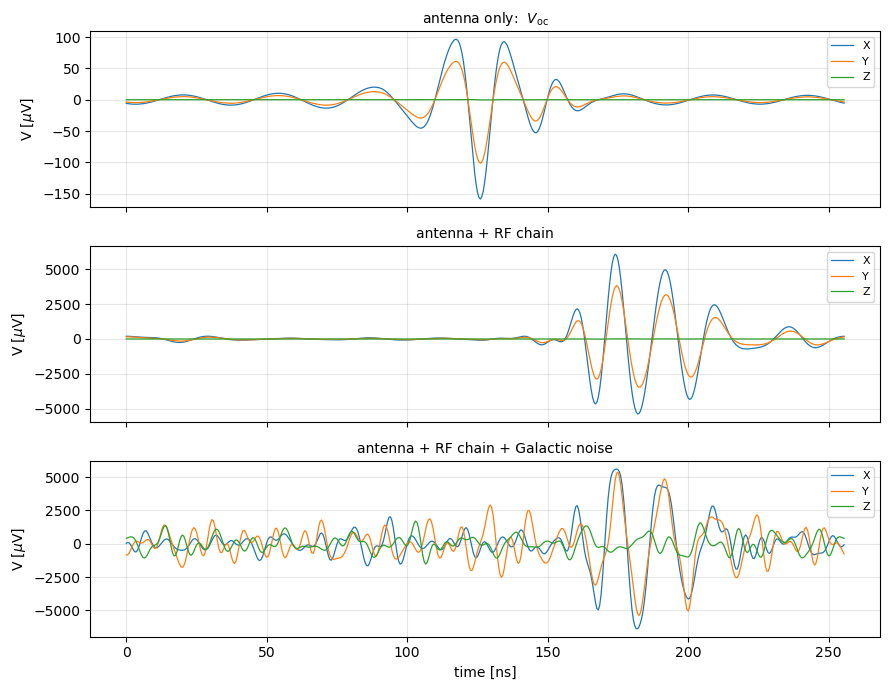

In [4]:
bare  = np.asarray(run_chain(add_noise=False, add_rf_chain=False).vout)  # V_oc only
chain = np.asarray(run_chain(add_noise=False).vout)                     # + RF chain
noise = vout - chain                                                    # exactly the noise

fig, ax = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
for a, (data, title) in zip(ax, [
        (bare,  r'antenna only:  $V_{\rm oc}$'),
        (chain, 'antenna + RF chain'),
        (vout,  'antenna + RF chain + Galactic noise')]):
    for i, arm in enumerate('XYZ'):
        a.plot(t_ns, data[0, i], lw=.9, label=arm)     # detection unit 0
    a.set_title(title, fontsize=10)
    a.grid(alpha=.3)
    a.legend(loc='upper right', fontsize=8)
    a.set_ylabel(r'V [$\mu$V]')
ax[-1].set_xlabel('time [ns]')
fig.tight_layout()

print("unit 0, per arm (X, Y, Z):")
print("   V_oc peak       ", np.round(np.abs(bare[0]).max(axis=-1), 1))
print("   + chain peak    ", np.round(np.abs(chain[0]).max(axis=-1), 1))
print("   noise RMS       ", np.round(np.std(noise[0], axis=-1), 1))
print("   signal / noise  ", np.round(np.abs(chain[0]).max(axis=-1)
                                      / np.std(noise[0], axis=-1), 1))

Several things to read off this.

**The RF chain amplifies and rings.** The gain is the factor notebook 04
measured. The sharp input pulse becomes an oscillation because the chain is
band-limited to 30–250 MHz, and a Gaussian narrower than that band cannot
survive it. The ringing is real and appears in data; it is also why you cannot
estimate the noise from "the part of the trace away from the pulse".

**Amplitude decides everything.** At 500 µV/m the X arm has a signal-to-noise
near 10 and is comfortably detectable. Drop the input to 1 µV/m and
$V_{\rm oc}$ falls to 0.3 µV against a noise RMS of several hundred — a
signal-to-noise of 0.03, invisible. GRAND's sensitivity is set by exactly this
ratio, which is why the open $\sqrt2$ question of notebook 05 is not a detail.

**The Z arm output is tiny — and not for the reason you would guess.**

## 4. A trap: arm X is not "the X component of E"

The input field has components in the ratio 1.0 : 0.6 : 0.2, but the output
arms come out closer to 600 : 400 : 1. The Z arm is not receiving 0.2 of the
signal; it is receiving almost none.

The reason is *not* that the Z arm is insensitive at this zenith angle. It is
the most sensitive of the three:

In [5]:
from grand.sim.detector.antenna_model import AntennaModel

model = AntennaModel()
f_mhz = model.leff_sn.frequency / 1e6
i_f = int(np.argmin(np.abs(f_mhz - 100.0)))

# Index 85 of the theta axis is zenith 85 deg, matching shower.zenith above.
# Averaging over azimuth because the shower azimuth enters through the frame
# rotation rather than through this index.
print("mean effective length at 100 MHz, zenith 85 deg (the shower geometry):")
for name, arm in model.d_leff.items():
    lt = np.abs(arm.leff_theta_reim[i_f, :, 85]).mean()
    lp = np.abs(arm.leff_phi_reim[i_f, :, 85]).mean()
    print("   %-4s |l_theta| = %.3f m   |l_phi| = %.3f m" % (name, lt, lp))

mean effective length at 100 MHz, zenith 85 deg (the shower geometry):
   sn   |l_theta| = 0.060 m   |l_phi| = 0.796 m
   ew   |l_theta| = 0.086 m   |l_phi| = 0.799 m
   z    |l_theta| = 0.603 m   |l_phi| = 0.011 m


The Z arm has by far the largest $|\ell_\theta|$ at this zenith. What is small
is the *projection*: the response is
$V_{\rm oc} = \boldsymbol{\ell}\cdot\boldsymbol{E}$ evaluated in the
$(\theta, \phi)$ basis of the **arrival direction**, not a per-axis gain
applied to the Cartesian components of the field. The Z arm responds through
$\ell_\theta$, so what reaches it is the $\theta$-component of the field for
this particular direction — which for this geometry is small.

The practical rule: **`trace[:, 2]` is the Z antenna arm, not $E_z$.** Any
analysis that treats the three arms as a Cartesian decomposition of the field
will be wrong, and wrong in a direction-dependent way that will not look like
an obvious bug.

## 5. In the frequency domain

The same three stages, seen spectrally, make the band limits obvious.

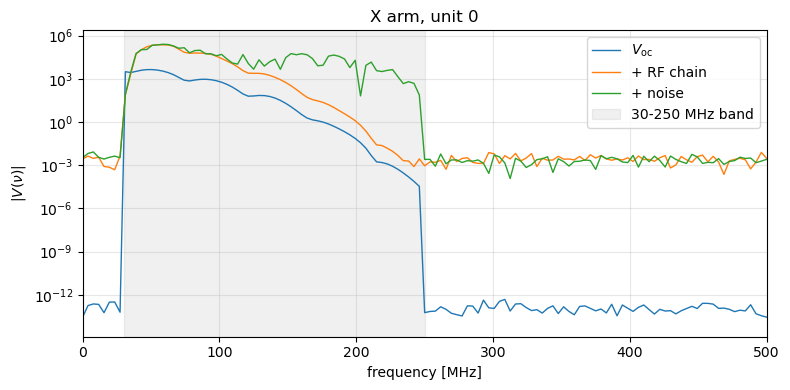

In [6]:
# rfftfreq needs the sample spacing in seconds; T_BIN_NS is nanoseconds.
freqs = np.fft.rfftfreq(N_SAMPLES, d=T_BIN_NS * 1e-9) / 1e6   # MHz

fig, ax = plt.subplots(figsize=(8, 4))
for data, name in [(bare, r'$V_{\rm oc}$'), (chain, '+ RF chain'), (vout, '+ noise')]:
    ax.semilogy(freqs, np.abs(np.fft.rfft(data[0, 0])), lw=1, label=name)

ax.axvspan(30, 250, color='k', alpha=.06, label='30-250 MHz band')
ax.set_xlabel('frequency [MHz]')
ax.set_ylabel(r'$|V(\nu)|$')
ax.set_xlim(0, 500)          # Nyquist is 1000 MHz; nothing lives above ~300
ax.set_title('X arm, unit 0')
ax.grid(alpha=.3, which='both')
ax.legend()
fig.tight_layout()

The RF chain's band-pass is unmistakable: outside 30–250 MHz the amplified
trace falls away sharply. The noise fills that band and nothing outside it,
because the tables of notebook 05 are only defined there.

## 6. Digitising

The last stage turns microvolts into ADC counts.

In [7]:
from grand.sim.detector.adc import ADC

adc = ADC()
print("ADC:", [a for a in dir(adc) if not a.startswith('_')])

# 1.8 V full scale across a 14-bit converter, expressed in microvolts so it can
# be compared with the traces above directly.
lsb_uv = 1.8e6 / 2 ** 14
print()
print("quantisation step   %.1f uV" % lsb_uv)
print("noise RMS, X arm    %.1f uV  ->  %.1f counts"
      % (np.std(noise[0, 0]), np.std(noise[0, 0]) / lsb_uv))
print("signal peak, X arm  %.1f uV  ->  %.0f counts"
      % (np.abs(chain[0, 0]).max(), np.abs(chain[0, 0]).max() / lsb_uv))

ADC: ['downsample', 'max_bit_value', 'max_voltage', 'process', 'sampling_rate']

quantisation step   109.9 uV
noise RMS, X arm    631.9 uV  ->  5.8 counts
signal peak, X arm  6076.7 uV  ->  55 counts


The noise sits several counts above the quantisation step, which is the
condition a well-designed digitiser has to meet: if the LSB were larger than
the noise, quantisation would dominate and information would be thrown away
before the trigger ever saw it.

## 7. Reading the result back

The chain wrote a `TVoltage` tree into its output file. Round-tripping it is
the check that the simulation and the data model actually agree.

In [8]:
voltage = TVoltage(full_sim.output_path)
voltage.get_entry(0)              # load event 0 into the branch buffers
back = np.asarray(voltage.trace)

print("read back:", back.shape, back.dtype)
# float32 on the way in, float64 on the way out, hence the tolerance.
print("matches what compute_voltage held:", np.allclose(back, vout, rtol=1e-5))
print("all finite:", np.isfinite(back).all())

read back: (3, 3, 512) float64
matches what compute_voltage held: True
all finite: True


## 8. What this pipeline does and does not do

Worth being explicit, because it is the most common misunderstanding about
GRANDlib.

**It does**: apply a measured instrument response to a given electric field,
add a modelled background, digitise, and record the result in a schema the
rest of the collaboration can read.

**It does not**: simulate the air shower, or the radio emission from it. Those
come from ZHAireS or CoREAS and are converted into `TEfield` by the `sim2root`
tools. GRANDlib is the middleware between a shower simulator and an analysis —
which is why the schema and the frame handling matter as much as the physics.

Three limitations that apply to any number produced here:

- absolute noise levels are subject to the open $\sqrt2$ question, and depend
  on `du_type` by up to a factor of two (notebook 05);
- `vga_gain` is ignored, so this is a 20 dB chain regardless of what is
  requested (notebook 04);
- the arms are not Cartesian field components (section 4).

In [9]:
import shutil

shutil.rmtree(workdir, ignore_errors=True)
print("cleaned up")

cleaned up


## Where next

- [02 — Reading and writing GRAND data](02_data_model.ipynb) — the schema this wrote into
- [05 — Galactic noise](05_galactic_noise.ipynb) — the background added above
- [07 — Topography](07_topography.ipynb) — where the detection units actually sit